# 50 - Intermediate conf60 4-class

**Dataset:** Front-only conf60 (confidence >= 60%)
**Skenario:** B1 (Baseline), B2 (Class Weights), B3 (Weights + Augmentasi)

In [1]:
import sys, os, json
import numpy as np
import torch
import torch.nn as nn
from pathlib import Path
from torch.utils.data import DataLoader
from collections import Counter

PROJECT_ROOT = Path("..").resolve()
sys.path.insert(0, str(PROJECT_ROOT / "src"))

from training.models import IntermediateFusion
from training.utils import (
    EmotionImageDataset, EmotionLandmarkDataset, EmotionMultimodalDataset,
    get_class_weights, train_model, full_evaluation,
    plot_training_history, plot_confusion_matrix, plot_per_class_f1
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")
if device.type == "cuda":
    print(f"GPU: {torch.cuda.get_device_name(0)}")

DATASET_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class"
DATASET_AUG_DIR = PROJECT_ROOT / "data" / "dataset_frontonly_conf60_4class_augmented"
OUTPUT_DIR = PROJECT_ROOT / "models" / "frontonly_conf60" / "4class"
os.makedirs(OUTPUT_DIR, exist_ok=True)

BATCH_SIZE = 32
EPOCHS = 50
LR = 0.0001
PATIENCE = 15
NUM_CLASSES = 4
EMOTIONS = ["neutral", "happy", "sad", "negative"]

print(f"Dataset: {DATASET_DIR}")
print(f"Dataset Aug: {DATASET_AUG_DIR}")
print(f"Output: {OUTPUT_DIR}")

Device: cuda
GPU: Tesla T4
Dataset: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class
Dataset Aug: /home/bs000716/MOTHER-TANK/TRAIN/data/dataset_frontonly_conf60_4class_augmented
Output: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class


In [2]:
def load_dataloaders(dataset_dir, batch_size=32):
    loaders = {}
    for split in ["train", "val", "test"]:
        ds = EmotionMultimodalDataset(dataset_dir / f"X_{split}_images.npy", dataset_dir / f"X_{split}_landmarks.npy", dataset_dir / f"y_{split}.npy")
        loaders[split] = DataLoader(ds, batch_size=batch_size, shuffle=(split=="train"), num_workers=2, pin_memory=True)
    y = np.load(dataset_dir / "y_train.npy")
    counts = Counter(y.tolist())
    print(f"Train: {len(y)} | Val: {len(np.load(dataset_dir / 'y_val.npy'))} | Test: {len(np.load(dataset_dir / 'y_test.npy'))}")
    for i, e in enumerate(EMOTIONS): print(f"  {e:>10s}: {counts.get(i, 0)}")
    return loaders["train"], loaders["val"], loaders["test"]

train_loader, val_loader, test_loader = load_dataloaders(DATASET_DIR, BATCH_SIZE)

Train: 5287 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 58


## Training B1, B2, B3


Training B1 (baseline)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9541     0.6698     0.8743    0.8238   0.2259   0.000100  (32.2s)


     2      0.5896     0.8532     0.7300    0.8238   0.2259   0.000100  (32.0s)


     3      0.5209     0.8549     0.7126    0.8221   0.2256   0.000100  (32.0s)


     4      0.4906     0.8559     0.7205    0.8152   0.2245   0.000100  (31.9s)


...

    23      0.2380     0.9177     0.6904    0.8169   0.3861   0.000050  (31.3s)


    24      0.2307     0.9187     0.7129    0.7997   0.3900   0.000050  (31.3s)


    25      0.2241     0.9240     0.7049    0.7893   0.3860   0.000050  (31.3s)


    26      0.2180     0.9242     0.7741    0.8204   0.3957   0.000050  (31.3s)


    27      0.2188     0.9223     0.7521    0.7789   0.3806   0.000050  (31.3s)

Early stopping at epoch 27. Best epoch: 12 (val_f1=0.4513)

Best: epoch 12, val_acc=0.8238, val_f1=0.4513
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/intermediate_b1.pth


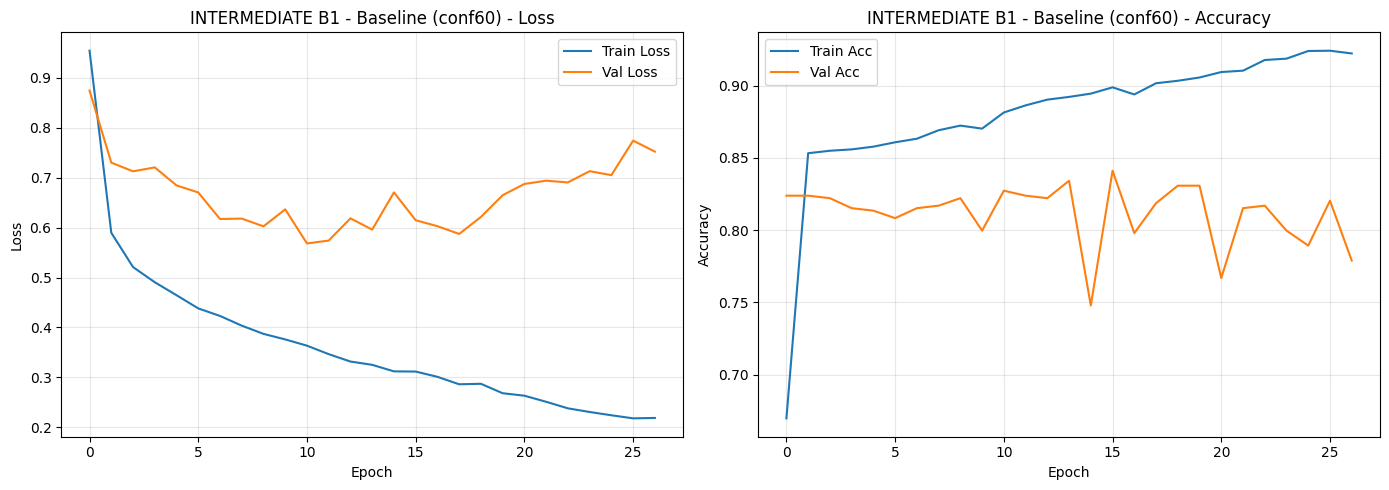

Test Loss: 0.5468
Test Accuracy: 0.7879
Test Macro F1: 0.4453
Test Weighted F1: 0.7885

Classification Report:
              precision    recall  f1-score   support

     neutral       0.90      0.84      0.87       688
       happy       0.59      0.80      0.68       183
         sad       0.25      0.22      0.23        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.79       929
   macro avg       0.44      0.46      0.45       929
weighted avg       0.80      0.79      0.79       929



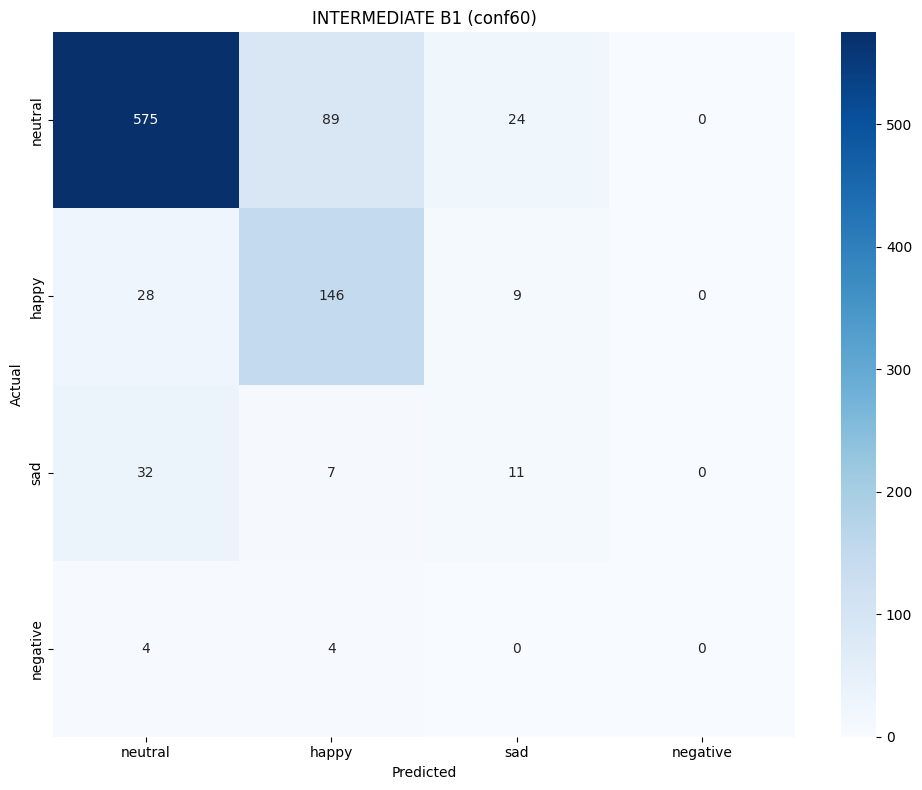

B1: Acc=0.7879 F1=0.4453

Class weights: None


Training B2 (class weights)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.8654     0.7144     0.8423    0.8238   0.2259   0.000100  (31.3s)


     2      0.5662     0.8549     0.7327    0.8221   0.2256   0.000100  (31.4s)


     3      0.5070     0.8551     0.7709    0.8204   0.2253   0.000100  (31.4s)


...

    23      0.2101     0.9251     0.8113    0.7634   0.3735   0.000050  (31.3s)


    24      0.2116     0.9281     0.8293    0.7945   0.3892   0.000050  (31.3s)


    25      0.2076     0.9285     0.8337    0.7910   0.3834   0.000050  (31.3s)


    26      0.2052     0.9287     0.8118    0.7634   0.3802   0.000050  (31.4s)


    27      0.2045     0.9298     0.7892    0.7876   0.3985   0.000050  (31.5s)

Early stopping at epoch 27. Best epoch: 12 (val_f1=0.4375)

Best: epoch 12, val_acc=0.8083, val_f1=0.4375
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/intermediate_b2.pth


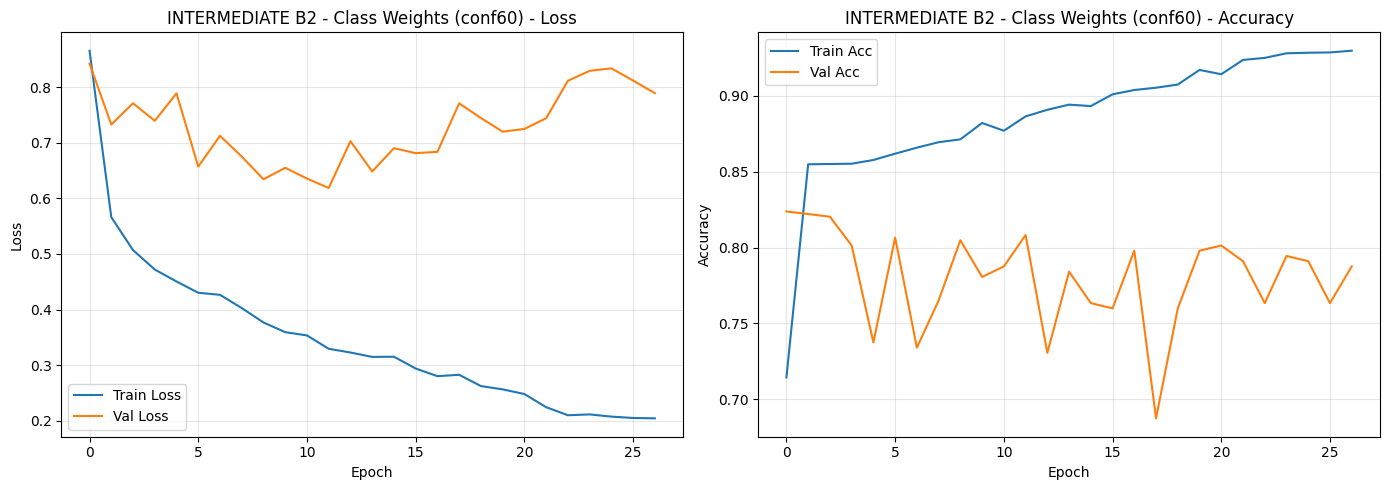

Test Loss: 0.5358
Test Accuracy: 0.7826
Test Macro F1: 0.4164
Test Weighted F1: 0.7785

Classification Report:
              precision    recall  f1-score   support

     neutral       0.89      0.85      0.87       688
       happy       0.56      0.76      0.65       183
         sad       0.21      0.12      0.15        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.78       929
   macro avg       0.42      0.43      0.42       929
weighted avg       0.78      0.78      0.78       929



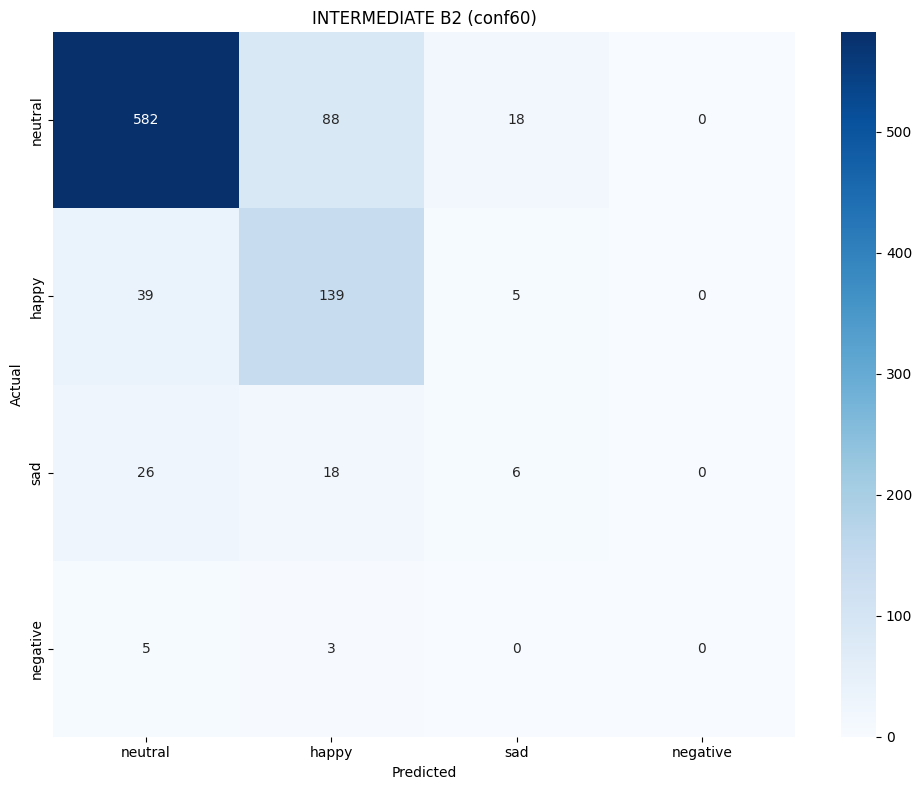

B2: Acc=0.7826 F1=0.4164


Train: 5829 | Val: 579 | Test: 929
     neutral: 4526
       happy: 416
         sad: 287
    negative: 600



Training B3 (class weights + augmented)...
 Epoch  Train Loss  Train Acc   Val Loss   Val Acc   Val F1         LR
---------------------------------------------------------------------------


     1      0.9212     0.6946     0.7622    0.8135   0.2243   0.000100  (35.0s)


     2      0.6694     0.8036     0.6561    0.8204   0.2253   0.000100  (35.7s)


...

    26      0.1579     0.9430     0.9255    0.8221   0.3487   0.000050  (35.4s)


    27      0.1574     0.9461     0.9296    0.8273   0.3539   0.000050  (35.4s)


    28      0.1552     0.9456     0.9343    0.8100   0.3786   0.000050  (35.4s)


    29      0.1435     0.9497     0.9843    0.8066   0.3367   0.000050  (35.6s)


    30      0.1442     0.9485     0.9359    0.7997   0.3608   0.000050  (35.5s)

Early stopping at epoch 30. Best epoch: 15 (val_f1=0.4098)

Best: epoch 15, val_acc=0.8359, val_f1=0.4098
Model saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/intermediate_b3.pth


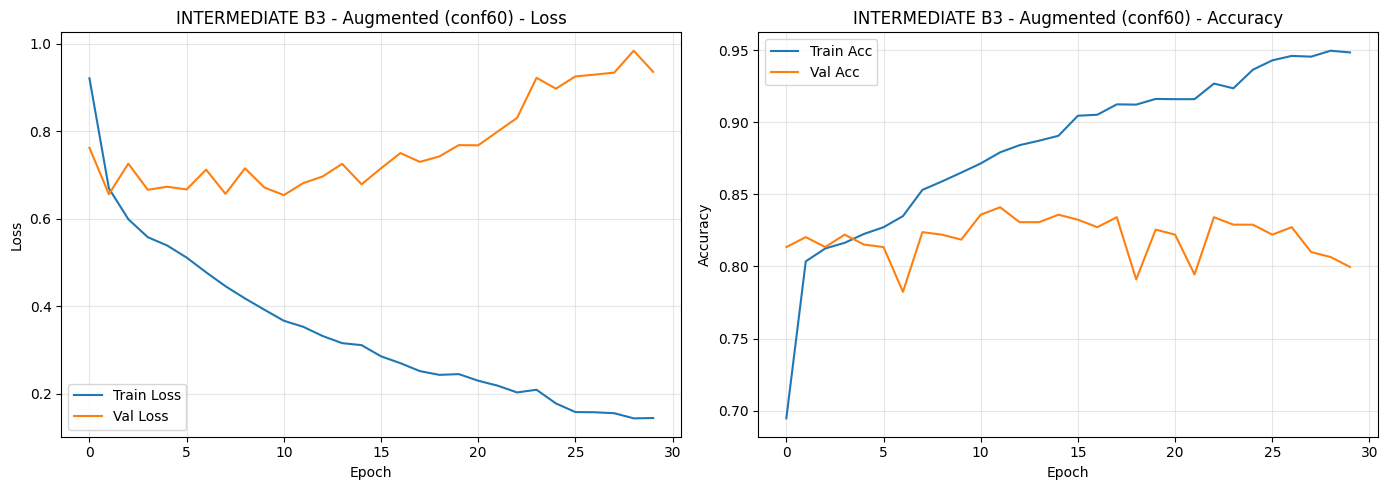

Test Loss: 0.5624
Test Accuracy: 0.7901
Test Macro F1: 0.3816
Test Weighted F1: 0.7611

Classification Report:
              precision    recall  f1-score   support

     neutral       0.82      0.94      0.87       688
       happy       0.67      0.47      0.55       183
         sad       0.30      0.06      0.10        50
    negative       0.00      0.00      0.00         8

    accuracy                           0.79       929
   macro avg       0.45      0.37      0.38       929
weighted avg       0.75      0.79      0.76       929



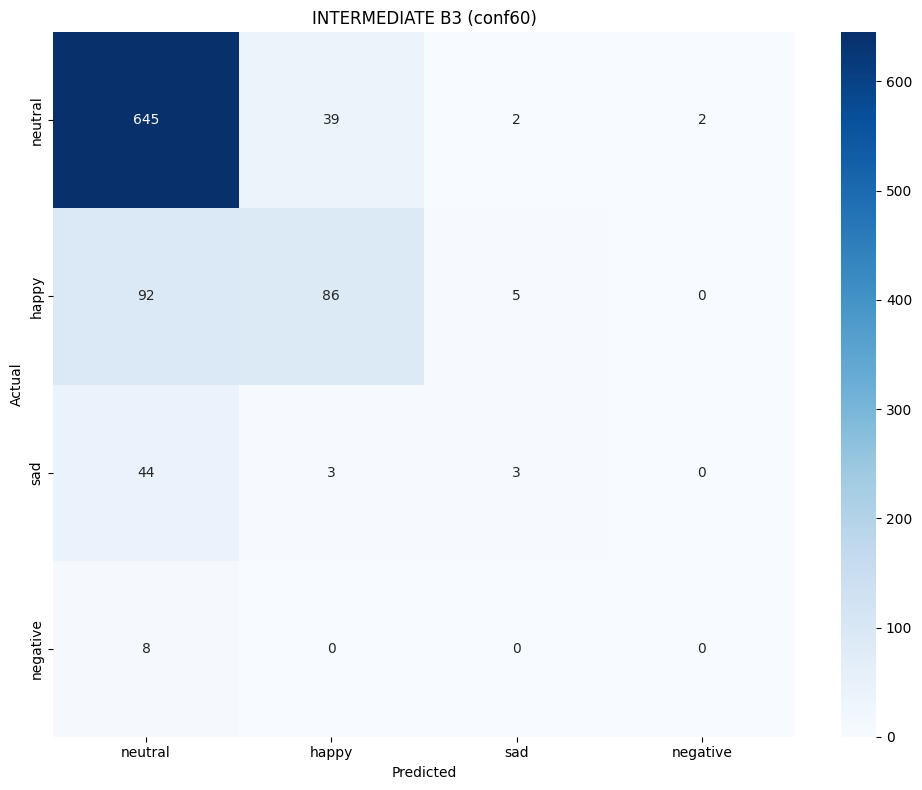

B3: Acc=0.7901 F1=0.3816

RINGKASAN INTERMEDIATE (conf60)
  B1 Baseline               Acc=0.7879 F1=0.4453
  B2 Class Weights          Acc=0.7826 F1=0.4164
  B3 Weights+Aug            Acc=0.7901 F1=0.3816

Saved: /home/bs000716/MOTHER-TANK/TRAIN/models/frontonly_conf60/4class/intermediate_results.json


In [3]:
all_results = {}

# B1: Baseline
model_b1 = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
criterion_b1 = nn.CrossEntropyLoss()
optimizer_b1 = torch.optim.Adam(model_b1.parameters(), lr=LR)
scheduler_b1 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b1, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B1 (baseline)...")
history_b1, _ = train_model(model_b1, train_loader, val_loader, criterion_b1, optimizer_b1, scheduler_b1,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_b1.pth"))
plot_training_history(history_b1, "INTERMEDIATE B1 - Baseline (conf60)")
model_b1.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b1.pth", map_location=device, weights_only=True))
r_b1 = full_evaluation(model_b1, test_loader, criterion_b1, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b1["confusion_matrix"], "INTERMEDIATE B1 (conf60)", EMOTIONS)
all_results["B1 Baseline"] = {"accuracy": float(r_b1["test_accuracy"]), "macro_f1": float(r_b1["test_macro_f1"]), "weighted_f1": float(r_b1["test_weighted_f1"])}
print(f"B1: Acc={r_b1['test_accuracy']:.4f} F1={r_b1['test_macro_f1']:.4f}")

# B2: Class Weights
weights = get_class_weights(DATASET_DIR, device)
print(f"\nClass weights: {weights}")
model_b2 = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
criterion_b2 = nn.CrossEntropyLoss(weight=weights)
optimizer_b2 = torch.optim.Adam(model_b2.parameters(), lr=LR)
scheduler_b2 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b2, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("Training B2 (class weights)...")
history_b2, _ = train_model(model_b2, train_loader, val_loader, criterion_b2, optimizer_b2, scheduler_b2,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_b2.pth"))
plot_training_history(history_b2, "INTERMEDIATE B2 - Class Weights (conf60)")
model_b2.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b2.pth", map_location=device, weights_only=True))
r_b2 = full_evaluation(model_b2, test_loader, criterion_b2, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b2["confusion_matrix"], "INTERMEDIATE B2 (conf60)", EMOTIONS)
all_results["B2 Class Weights"] = {"accuracy": float(r_b2["test_accuracy"]), "macro_f1": float(r_b2["test_macro_f1"]), "weighted_f1": float(r_b2["test_weighted_f1"])}
print(f"B2: Acc={r_b2['test_accuracy']:.4f} F1={r_b2['test_macro_f1']:.4f}")

# B3: Class Weights + Augmented
train_loader_aug, _, _ = load_dataloaders(DATASET_AUG_DIR, BATCH_SIZE)
weights_aug = get_class_weights(DATASET_AUG_DIR, device)
model_b3 = IntermediateFusion(num_classes=NUM_CLASSES).to(device)
criterion_b3 = nn.CrossEntropyLoss(weight=weights_aug)
optimizer_b3 = torch.optim.Adam(model_b3.parameters(), lr=LR)
scheduler_b3 = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer_b3, mode="max", factor=0.5, patience=8, min_lr=1e-7)
print("\nTraining B3 (class weights + augmented)...")
history_b3, _ = train_model(model_b3, train_loader_aug, val_loader, criterion_b3, optimizer_b3, scheduler_b3,
    device, model_type="fusion", epochs=EPOCHS, patience=PATIENCE, save_path=str(OUTPUT_DIR / "intermediate_b3.pth"))
plot_training_history(history_b3, "INTERMEDIATE B3 - Augmented (conf60)")
model_b3.load_state_dict(torch.load(OUTPUT_DIR / "intermediate_b3.pth", map_location=device, weights_only=True))
r_b3 = full_evaluation(model_b3, test_loader, criterion_b3, device, "fusion", EMOTIONS)
plot_confusion_matrix(r_b3["confusion_matrix"], "INTERMEDIATE B3 (conf60)", EMOTIONS)
all_results["B3 Weights+Aug"] = {"accuracy": float(r_b3["test_accuracy"]), "macro_f1": float(r_b3["test_macro_f1"]), "weighted_f1": float(r_b3["test_weighted_f1"])}
print(f"B3: Acc={r_b3['test_accuracy']:.4f} F1={r_b3['test_macro_f1']:.4f}")

# Summary
print("\n" + "=" * 60)
print("RINGKASAN INTERMEDIATE (conf60)")
print("=" * 60)
for name, r in all_results.items():
    print(f"  {name:<25} Acc={r['accuracy']:.4f} F1={r['macro_f1']:.4f}")

with open(OUTPUT_DIR / "intermediate_results.json", "w") as f:
    json.dump(all_results, f, indent=2)
print(f"\nSaved: {OUTPUT_DIR / 'intermediate_results.json'}")